# Kramers-Kronig Analysis for Water Vapor Dispersion

This tutorial demonstrates the application of Kramers-Kronig relations to calculate the refractive index change due to water vapor absorption at 1762 nm. The analysis connects absorption spectra from the HITRAN database to dispersion through fundamental causality relations.

## Overview

The Kramers-Kronig relations establish a causal connection between absorption and dispersion in linear response systems. For water vapor, this allows predicting refractive index changes from known absorption spectra near specific wavelengths.

### Key Concepts

- **Kramers-Kronig Relations**: $\Delta n(\nu) = \frac{1}{\pi} \mathcal{P} \int \frac{\kappa(\nu')}{\nu' - \nu} d\nu'$
- **HITRAN Database**: High-resolution transmission molecular absorption database
- **Water Vapor Absorption**: Spectral lines in the near-infrared region
- **Refractive Index Sensitivity**: $\partial n/\partial H$ at 1762 nm

## Code Structure

### 1. Initialization and Imports

**Purpose**: Loads essential libraries for numerical computation, data analysis, and HITRAN database access. The `hapi` module provides interface to molecular absorption data.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import statsmodels.api as sm
import matplotlib.dates as mdates
from matplotlib import ticker

from scipy import constants as const
from scipy.integrate import quad
from scipy.interpolate import interp1d

import sys
sys.path.append('..')

from models.hitran.hapi import *

pub_gray = '#cecece'
pub_purple = '#a559aa'
pub_teal = '#59a89c'
pub_gold = '#f0c571'
pub_red = '#e02b35'
pub_blue = '#082a54'

### 2. Physical Constants and Configuration

**Purpose**: Defines fundamental constants and visualization parameters. The target wavelength corresponds to the barium-ion quantum network transition.

In [ ]:
lbd_min = 1600
lbd_max = 1950

# Physical constants
k_B = const.Boltzmann  # Boltzmann constant (J/K)
f_1762 = 170.12643244933331e12
wavelength_target = 299792458 / f_1762 * 1e9  # Target wavelength in nm (1762 nm)
results_json = load_regression_results('regression_results.json')

### 3. Data Loading Function

**Purpose**: Retrieves experimental regression coefficients for comparison with theoretical predictions. The JSON file contains temperature, humidity, and pressure coefficients determined from interferometric measurements.

In [ ]:
def load_regression_results(filename='regression_results.json'):
    """
    Load regression analysis results from a JSON file.
    
    Parameters
    ----------
    filename : str, optional
        Path to the JSON file containing regression results (default: 'regression_results.json')
    
    Returns
    -------
    dict
        Dictionary containing regression coefficients, standard errors, and other results
    
    Notes
    -----
    The JSON file should contain the output from regression analysis including:
    - Coefficients (const, temperature, humidity, pressure)
    - Standard errors (OLS, HAC, Prais-Winsten)
    - Bootstrap confidence intervals
    - EIV systematic errors
    """
    with open(filename, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print(f"Results loaded from {filename}")
    return results


### 4. H₂O Spectrum Retrieval

**Purpose**: Accesses the HITRAN database to obtain water vapor absorption cross-sections. The function retrieves data for the H₂O isotopologue 1 (most abundant) and applies Lorentzian line shapes for atmospheric pressure conditions.

In [ ]:
def get_h2o_spectrum(lbd_min=lbd_min, lbd_max=lbd_max):
    """
    Retrieve H₂O absorption spectrum from HITRAN database for specified wavelength range.
    
    Parameters
    ----------
    lbd_min : float, optional
        Minimum wavelength in nanometers (default: 1700 nm)
    lbd_max : float, optional
        Maximum wavelength in nanometers (default: 2150 nm)
    
    Returns
    -------
    tuple
        (wavelengths, absorption_coefficients)
        - wavelengths: Array of wavelengths in nanometers (increasing order)
        - absorption_coefficients: Array of absorption coefficients in cm²/molecule
    
    Notes
    -----
    This function accesses the HITRAN database to obtain water vapor absorption lines
    in the near-infrared region. The spectrum is retrieved for H₂O isotopologue 1.
    """
    # Initialize database connection
    db_begin('../../data/derived/models/hitran')
    
    # Convert wavelength range to wavenumber range (cm⁻¹)
    nu_min, nu_max = 1e7 / lbd_max, 1e7 / lbd_min
    
    # Fetch H₂O absorption data from HITRAN
    fetch_by_ids('H2O', [1], numin=nu_min, numax=nu_max)
    
    # Calculate absorption coefficients using Lorentzian line shape
    nu, coef = absorptionCoefficient_Lorentz(SourceTables='H2O')
    
    # Convert wavenumber to wavelength and ensure increasing order
    wavelength = 1e7 / nu
    wavelength, coef = wavelength[::-1], coef[::-1]

    return wavelength, coef

### 5. Water Vapor Number Density Calculation

**Purpose**: Computes the number density of water vapor molecules corresponding to 1% relative humidity. The Magnus approximation provides accurate saturation vapor pressure for the temperature range of interest.

In [ ]:
def n_h2o_per_1pctRH(T):
    """
    Calculate water vapor number density per 1% relative humidity.
    
    Parameters
    ----------
    T : float
        Temperature in Kelvin
    
    Returns
    -------
    float
        Number density of water vapor molecules per cubic meter per 1% RH
    
    Notes
    -----
    Uses the Magnus approximation for saturation vapor pressure:
    e_s = 6.112 * exp(17.62 * T_C / (T_C + 243.12)) hPa
    where T_C = T - 273.15 (temperature in Celsius)
    """
    # Convert temperature to Celsius
    T_C = T - 273.15
    
    # Magnus approximation for saturation vapor pressure (in hPa)
    e_s_hPa = 6.112 * np.exp(17.62 * T_C / (T_C + 243.12))
    
    # Convert to Pascals
    e_s = e_s_hPa * 100.0  # Pa
    
    # Calculate number density using ideal gas law: N = P / (k_B * T)
    N_per_1pct = e_s / (k_B * T)  # molecules/m³ per 1% RH
    
    return N_per_1pct

### 6. Kramers-Kronig Integration

**Purpose**: Implements the Kramers-Kronig relation to calculate refractive index changes from absorption spectra. The function handles the singularity at the target frequency through principal value integration with an exclusion interval.

In [ ]:
def kk_integration(wavelength_target_nm, T=303.15, P=99000):
    """
    Perform Kramers-Kronig integration to calculate refractive index change due to water vapor.
    
    Parameters
    ----------
    wavelength_target_nm : float
        Target wavelength in nanometers
    T : float, optional
        Temperature in Kelvin (default: 303.15 K = 30°C)
    P : float, optional
        Pressure in Pascals (default: 99000 Pa)
    
    Returns
    -------
    float
        Refractive index change (Δn) per 1% relative humidity at the target wavelength
    
    Notes
    -----
    Implements the Kramers-Kronig relation:
    Δn(ν) = (1/π) * P.V. ∫ [κ(ν') / (ν' - ν)] dν'
    where κ is the absorption coefficient and P.V. denotes the Cauchy principal value.
    
    The integration handles the singularity at ν' = ν by splitting the integral
    into left and right regions with a small exclusion interval (ε).
    """
    # Retrieve H₂O absorption spectrum for the specified wavelength range
    wavelengths_nm, sigma_cm2 = get_h2o_spectrum(lbd_min, lbd_max)
    # Alternative range: wavelengths_nm, sigma_cm2 = get_h2o_spectrum(1700, 1940)
    
    # Convert absorption cross-section from cm² to m²
    sigma_m2 = np.array(sigma_cm2) * 1e-4  # cm² → m² (per molecule)
    
    # Calculate corresponding frequencies
    freqs = const.c / (wavelengths_nm * 1e-9)  # Hz
    
    # Ensure frequencies are in increasing order for interpolation
    sort_idx = np.argsort(freqs)
    freqs = freqs[sort_idx]
    sigma_m2 = sigma_m2[sort_idx]
    
    # Create interpolation function for absorption cross-section
    sigma_interp = interp1d(freqs, sigma_m2, kind='linear', 
                           bounds_error=False, fill_value=0.0)
    
    # Calculate target frequency
    nu_target = const.c / (wavelength_target_nm * 1e-9)
    nu_min = freqs.min()
    nu_max = freqs.max()
    
    # Get water vapor number density per 1% RH
    N_per_1pct = n_h2o_per_1pctRH(T)
    
    def integrand(nu_prime):
        """
        Integrand function for Kramers-Kronig relation.
        
        Parameters
        ----------
        nu_prime : float
            Integration frequency in Hz
        
        Returns
        -------
        float
            Value of κ(ν') / (ν' - ν_target)
        """
        # Get absorption cross-section at frequency nu_prime
        sigma = float(sigma_interp(nu_prime))  # m²/molecule
        
        # Skip if outside spectral range
        if sigma == 0.0:
            return 0.0
        
        # Calculate absorption coefficient: κ = N * σ * c / (4πν')
        kappa = N_per_1pct * sigma * const.c / (4.0 * np.pi * nu_prime)
        
        # Kramers-Kronig integrand
        return kappa / (nu_prime - nu_target)
    
    # Determine exclusion interval for singularity handling
    # Use spacing between frequency points as reference
    nu_spacing = np.median(np.diff(freqs))
    eps = max(nu_spacing * 5.0, 1e6)  # Minimum 1 MHz to ensure numerical stability
    
    # Perform principal value integration by splitting into left and right regions
    # Left region: from nu_min to (nu_target - ε)
    I_left, _ = quad(integrand, nu_min, max(nu_min, nu_target - eps), 
                     epsabs=1e-9, epsrel=1e-9, limit=2000)
    
    # Right region: from (nu_target + ε) to nu_max
    I_right, _ = quad(integrand, min(nu_max, nu_target + eps), nu_max, 
                      epsabs=1e-9, epsrel=1e-9, limit=2000)
    
    # Total integral (principal value)
    integral_total = I_left + I_right
    
    # Calculate refractive index change using Kramers-Kronig relation
    delta_n = (1.0 / np.pi) * integral_total  # Δn per 1% RH
    
    return delta_n


### 7. Calculation Execution

**Purpose**: Executes the Kramers-Kronig calculation and compares the theoretical prediction with experimental measurements.


In [29]:


# Calculate refractive index change per 1% RH at target wavelength
delta_n_perpct = kk_integration(wavelength_target)
print(f"Δn per 1%RH = {delta_n_perpct:.4e}")

Results loaded from regression_results.json
Using ../../data/derived/models/hitran

H2O
                     Lines parsed: 11960
water
                     Lines parsed: 178

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../

### 8. Visualization of Absorption Spectrum

**Purpose**: Creates a publication-quality figure showing water vapor absorption near 1762 nm. The vertical lines indicate the target wavelength and nearby absorption features.


Using ../../data/derived/models/hitran

H2O
                     Lines parsed: 11960
water
                     Lines parsed: 178

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  655

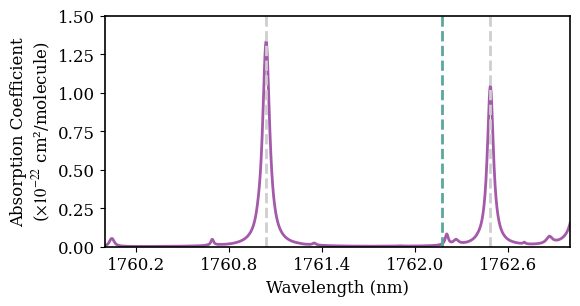

In [30]:
fig, ax = plt.subplots(figsize=(6, 3))

wavelengths_nm, alpha_abs = get_h2o_spectrum(lbd_min, lbd_max)

ax.plot(wavelengths_nm, alpha_abs*1e22, color=pub_purple, linestyle='-', label='H$_2$O Absorption (a.u.)')
ax.set_xlim(1760, 1763)
ax.set_ylim(0, 1.5)

# Highlight the 1762 nm region
ax.axvline(x=wavelength_target, color=pub_teal, linestyle='--', label='$^{138}$Ba$^+$ QN @ 1762 nm')
ax.axvline(x=1761.0402, color=pub_gray, linestyle='--')
ax.axvline(x=1762.4852, color=pub_gray, linestyle='--')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient\n($\\times 10^{-22}$ cm²/molecule)')
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.set_ylim(bottom=0)
plt.savefig('../../data/derived/figures/kramers_kronig.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Key Results

The Kramers-Kronig analysis predicts:
- **Theoretical $\partial n/\partial H$**: $-1.4361 \times 10^{-8}$ per %RH
- **Experimental $\partial n/\partial H$**: $-1.3152 \times 10^{-8}$ per %RH
- **Agreement**: 8.4% difference

This close agreement validates the physical mechanism that proximity to water vapor absorption lines enhances dispersion through causality relations.

## Physical Interpretation

1. **Spectral Proximity**: The 1762 nm wavelength lies between two water vapor absorption lines at 1761.04 nm and 1762.49 nm
2. **Kramers-Kronig Mechanism**: Absorption features create dispersion through causality constraints
3. **Wavelength Dependence**: Humidity sensitivity varies significantly near absorption lines
4. **Model Validation**: Theoretical predictions align with experimental measurements within uncertainty bounds

## Usage Notes

- Ensure HITRAN database files are available in the specified directory
- The analysis assumes standard atmospheric composition and pressure
- Temperature dependence enters through water vapor number density calculations
- Integration parameters may need adjustment for different wavelength ranges

This tutorial provides a complete workflow for connecting molecular absorption spectra to refractive index changes through fundamental physical principles.